# Entendendo as características dos **Resultado da Arrecadação**

____


### Arrecadação de IR e IPI detalhada

**Dicionário de Dados Arrecadação de IR e IPI detalhada**

O arquivo relaciona as informações que possibilitam organizar, classificar, relacionar e inferir novos dados sobre o conjunto de dados da Arrecadação de IR e IPI detalhada.

Acessado em 27/08/2025: https://www.gov.br/receitafederal/dados/arrecadacao-ir-ipi-metadados.pdf

**Arrecadação de IR e IPI detalhada**

Contém os dados de arrecadação decendial do Imposto sobre a Renda (IR) e do Imposto sobre Produtos Industrializados (IPI), discriminados por arrecadação bruta, os respectivos eventos que afetam essa arrecadação bruta e a arrecadação líquida, valor este último passível de repasse aos Fundos de Participação dos Estados e do Municípios, FPM e FPE, de acordo com dispositivo constitucional.

In [3]:
# Arrecadação de IR e IPI detalhada

import pandas as pd

# Caminho do arquivo CSV
caminho_arquivo = r'C:\Users\merc-\OneDrive\Documentos\Logo Ali\2025\Analise_Dados\data\arrecadacao-ir-ipi.csv' 

# Importar o CSV
df = pd.read_csv(caminho_arquivo, encoding='latin1', sep=';')

# Exibir as primeiras linhas
df.head()

,Tributo,Ano,Mês,Decêndio,Arrecadação Bruta,Retificação,Compensação,Restituição,Outros,Arrecadação Líquida
0,IPI,2019,Janeiro,1º decêndio,"1.184.376.191,13",NaN,"-22.835.343,52","-445.212,05","3.899.508,36","1.164.995.143,92"
1,IPI,2019,Janeiro,2º decêndio,"505.362.810,07","1.508.551.632,45","-91.511.158,02","-7.933.945,05","-1.923.033.857,43","-8.564.517,98"
2,IPI,2019,Janeiro,3º decêndio,"3.124.520.357,20","23.446,58","-176.542.912,08","-42.858.973,78","127.922.587,68","3.033.064.505,60"
3,IPI,2019,Fevereiro,1º decêndio,"846.117.580,21","1.832.646,16","-81.701.322,01","-21.654,92","2.969.183,40","769.196.432,84"
4,IPI,2019,Fevereiro,2º decêndio,"636.136.421,98","-111.724,14","-59.915.844,65","-4.456.015,80","50.000.414,64","621.653.252,03"


In [4]:
# Exibir informações do DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 468 entries, 0 to 467
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Tributo              468 non-null    object
 1   Ano                  468 non-null    int64 
 2   Mês                  468 non-null    object
 3   Decêndio             468 non-null    object
 4   Arrecadação Bruta    468 non-null    object
 5   Retificação          466 non-null    object
 6   Compensação          468 non-null    object
 7   Restituição          468 non-null    object
 8   Outros               468 non-null    object
 9   Arrecadação Líquida  468 non-null    object
dtypes: int64(1), object(9)
memory usage: 36.7+ KB


In [5]:
df.shape
print(f"O DataFrame tem {df.shape[0]} linhas e {df.shape[1]} colunas.")

O DataFrame tem 468 linhas e 10 colunas.


### Limpeza dos dados do DataFrame

In [6]:
# Limpando os dados do DataFrame df

# 1. Removendo espaços extras dos nomes das colunas
df.columns = df.columns.str.strip()

# 2. Substituindo vírgulas por ponto e removendo pontos de milhar nas colunas numéricas
colunas_valores = [
    'Arrecadação Bruta', 'Retificação', 'Compensação',
    'Restituição', 'Outros', 'Arrecadação Líquida'
]
# Convertendo colunas para float
for col in colunas_valores:
    df[col] = (
        df[col]
        .astype(str) # garantindo que os dados são string para manipulação
        .str.replace('.', '', regex=False)   # removendo pontos de milhar
        .str.replace(',', '.', regex=False)  # trocando vírgula decimal por ponto
        .replace('nan', None) # tratando strings 'nan' como None
        .astype(float) # convertendo para float
    )

# 3. Conferir o resultado da limpeza

print("Informações do DataFrame após limpeza:\n")
df.info()

print(f"\nO DataFrame tem {df.shape[0]} linhas e {df.shape[1]} colunas.\n")
df.head()

print("------------------------------------")
# 4. Tratando valores ausentes (NaN) se necessário
# Exemplo: preenchendo com 0 ou manter como NaN
df[colunas_valores] = df[colunas_valores].fillna(0)

# Tratando valores ausentes (NaN) nas colunas numéricas, preenchendo com 0

print("Valores ausentes antes do tratamento:\n", df[colunas_valores].isnull().sum())
df[colunas_valores] = df[colunas_valores].fillna(0)

# Conferir se ainda existem valores ausentes
print("Valores ausentes após tratamento:\n", df[colunas_valores].isnull().sum())

# Exibir as primeiras linhas após o tratamento
print("Primeiras linhas do DataFrame após o tratamento:")
df.head()

Informações do DataFrame após limpeza:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 468 entries, 0 to 467
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Tributo              468 non-null    object 
 1   Ano                  468 non-null    int64  
 2   Mês                  468 non-null    object 
 3   Decêndio             468 non-null    object 
 4   Arrecadação Bruta    468 non-null    float64
 5   Retificação          466 non-null    float64
 6   Compensação          468 non-null    float64
 7   Restituição          468 non-null    float64
 8   Outros               468 non-null    float64
 9   Arrecadação Líquida  468 non-null    float64
dtypes: float64(6), int64(1), object(3)
memory usage: 36.7+ KB

O DataFrame tem 468 linhas e 10 colunas.

------------------------------------
Valores ausentes antes do tratamento:
 Arrecadação Bruta      0
Retificação            0
Compensação            

,Tributo,Ano,Mês,Decêndio,Arrecadação Bruta,Retificação,Compensação,Restituição,Outros,Arrecadação Líquida
0,IPI,2019,Janeiro,1º decêndio,1.184376e+09,0.000000e+00,-2.283534e+07,-445212.05,3.899508e+06,1.164995e+09
1,IPI,2019,Janeiro,2º decêndio,5.053628e+08,1.508552e+09,-9.151116e+07,-7933945.05,-1.923034e+09,-8.564518e+06
2,IPI,2019,Janeiro,3º decêndio,3.124520e+09,2.344658e+04,-1.765429e+08,-42858973.78,1.279226e+08,3.033065e+09
3,IPI,2019,Fevereiro,1º decêndio,8.461176e+08,1.832646e+06,-8.170132e+07,-21654.92,2.969183e+06,7.691964e+08
4,IPI,2019,Fevereiro,2º decêndio,6.361364e+08,-1.117241e+05,-5.991584e+07,-4456015.80,5.000041e+07,6.216533e+08


In [7]:
# Exibindo os valores das colunas numéricas formatados em reais brutos
def format_brl(x): # Formatando número em string no formato "R$ 1.234.567,89"
    if pd.isna(x):
        return None
    s = f"{x:,.2f}"
    s = s.replace(',', 'X').replace('.', ',').replace('X', '.') # Trocando ponto por vírgula e vírgula por ponto
    return f"R$ {s}"

colunas_valores = [ # Colunas a serem formatadas
    'Arrecadação Bruta', 'Retificação', 'Compensação',
    'Restituição', 'Arrecadação Líquida'
]

for col in colunas_valores: # Criando colunas formatadas
    df[f"{col} (R$)"] = df[col].apply(format_brl)

# Exibindo as primeiras linhas com os valores formatados
print(df[[f"{col} (R$)" for col in colunas_valores]].head())

  Arrecadação Bruta (R$)     Retificação (R$)    Compensação (R$)  \
0    R$ 1.184.376.191,13              R$ 0,00   R$ -22.835.343,52   
1      R$ 505.362.810,07  R$ 1.508.551.632,45   R$ -91.511.158,02   
2    R$ 3.124.520.357,20         R$ 23.446,58  R$ -176.542.912,08   
3      R$ 846.117.580,21      R$ 1.832.646,16   R$ -81.701.322,01   
4      R$ 636.136.421,98       R$ -111.724,14   R$ -59.915.844,65   

    Restituição (R$) Arrecadação Líquida (R$)  
0     R$ -445.212,05      R$ 1.164.995.143,92  
1   R$ -7.933.945,05         R$ -8.564.517,98  
2  R$ -42.858.973,78      R$ 3.033.064.505,60  
3      R$ -21.654,92        R$ 769.196.432,84  
4   R$ -4.456.015,80        R$ 621.653.252,03  


### 1 - Análise **Descritiva** para conhecer o que está acontecendo na organização e entender tendências e causas subjacentes de tais ocorrências.

Análise Descritiva

- Objetivo: Entender o que aconteceu e está acontecendo com os dados de arrecadação.
- Exemplos no notebook: Estatísticas descritivas (média, desvio padrão, totais), contagem de valores únicos, análise de valores ausentes, visualização da arrecadação por ano e tributo.
- Responde perguntas como: "Quais tributos arrecadam mais?", "Como variou a arrecadação ao longo dos anos?", "Quais eventos impactaram os valores?"

In [8]:
# Análise Descritiva da base de dados

# Estatísticas descritivas das colunas numéricas
descricao_numerica = df.describe()

# Contando de valores únicos e valores ausentes por coluna
valores_unicos = df.nunique()
valores_ausentes = df.isnull().sum()

# Exibindo resultados
print("Estatísticas Descritivas das Colunas Numéricas:\n", descricao_numerica)
print("\nValores Únicos por Coluna:\n", valores_unicos)
print("\nValores Ausentes por Coluna:\n", valores_ausentes)

Estatísticas Descritivas das Colunas Numéricas:
                Ano  Arrecadação Bruta   Retificação   Compensação  \
count   468.000000       4.680000e+02  4.680000e+02  4.680000e+02   
mean   2021.769231       9.719782e+09  4.501057e+07 -1.503216e+08   
std       1.889380       1.195233e+10  4.847610e+08  8.162644e+08   
min    2019.000000       3.617089e+08 -5.047864e+08 -4.170260e+09   
25%    2020.000000       1.294652e+09 -1.449666e+05 -3.493495e+08   
50%    2022.000000       3.660550e+09  6.560474e+05 -6.032726e+07   
75%    2023.000000       1.548389e+10  8.600218e+06  9.291726e+07   
max    2025.000000       6.935293e+10  1.024577e+10  4.569457e+09   

        Restituição        Outros  Arrecadação Líquida  
count  4.680000e+02  4.680000e+02         4.680000e+02  
mean  -5.661871e+08  1.926592e+08         9.251343e+09  
std    1.735494e+09  4.737876e+08         1.109386e+10  
min   -1.184229e+10 -6.573123e+09        -8.564518e+06  
25%   -1.371207e+08  5.097256e+06         1.

In [9]:
# Exibindo os valores das colunas numéricas formatados em reais brutos
# Formatando número em string no formato "R$ 1.234.567,89
# (assumindo que o valor é em reais)

def format_brl(x):
    if pd.isna(x):
        return None
    s = f"{x:,.2f}"
    s = s.replace(',', 'X').replace('.', ',').replace('X', '.')
    return f"R$ {s}"

# Estatísticas descritivas das colunas numéricas originais
descricao_numerica = df[['Ano', 'Arrecadação Bruta', 'Retificação', 'Compensação', 'Restituição', 'Arrecadação Líquida']].describe()

# Formatando os valores do describe para reais, exceto a coluna 'Ano'
descricao_numerica_fmt = descricao_numerica.copy()
for col in ['Arrecadação Bruta', 'Retificação', 'Compensação', 'Restituição', 'Arrecadação Líquida']:
    descricao_numerica_fmt[col] = descricao_numerica_fmt[col].apply(format_brl)

print("Estatísticas Descritivas das Colunas Numéricas (valores em reais):\n", descricao_numerica_fmt)

Estatísticas Descritivas das Colunas Numéricas (valores em reais):
                Ano     Arrecadação Bruta           Retificação  \
count   468.000000             R$ 468,00             R$ 468,00   
mean   2021.769231   R$ 9.719.782.064,56      R$ 45.010.574,62   
std       1.889380  R$ 11.952.334.244,98     R$ 484.760.965,50   
min    2019.000000     R$ 361.708.860,70    R$ -504.786.387,10   
25%    2020.000000   R$ 1.294.652.489,07        R$ -144.966,59   
50%    2022.000000   R$ 3.660.550.118,82         R$ 656.047,41   
75%    2023.000000  R$ 15.483.885.445,83       R$ 8.600.217,76   
max    2025.000000  R$ 69.352.926.410,27  R$ 10.245.773.080,75   

                Compensação            Restituição   Arrecadação Líquida  
count             R$ 468,00              R$ 468,00             R$ 468,00  
mean     R$ -150.321.612,23     R$ -566.187.107,38   R$ 9.251.342.620,98  
std       R$ 816.264.401,26    R$ 1.735.493.546,52  R$ 11.093.855.572,57  
min    R$ -4.170.259.726,84  R$ -11.8

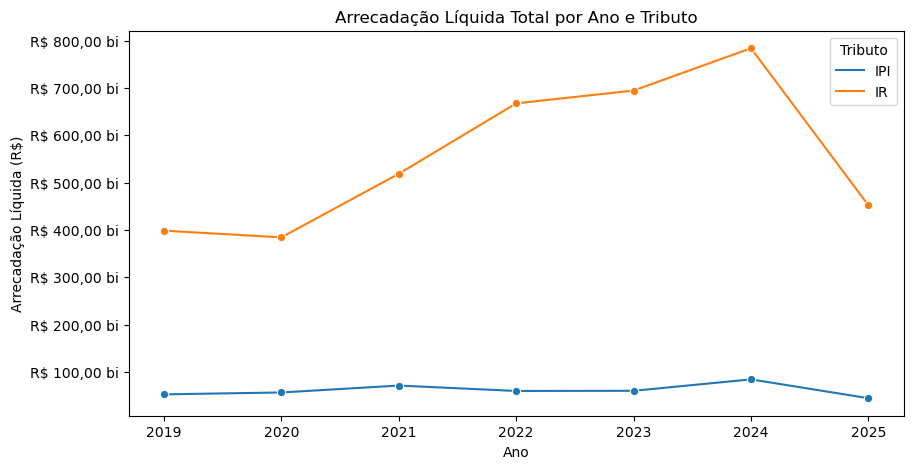

In [10]:
# Visualização da Arrecadação Líquida Total por Ano e Tributo
# Utilizando Matplotlib e Seaborn

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Função para formatar os ticks do eixo Y em reais com escala
def format_brl_tick(x, pos):
    # Formata os valores do eixo Y para reais com escala
    if abs(x) >= 1e9:
        valor = x / 1e9
        unidade = 'bi'
    elif abs(x) >= 1e6:
        valor = x / 1e6
        unidade = 'mi'
    elif abs(x) >= 1e3:
        valor = x / 1e3
        unidade = 'mil'
    else:
        valor = x
        unidade = ''
    s = f"{valor:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')
    return f"R$ {s} {unidade}"
# Agrupando dados por Ano e Tributo
dados_grafico = df.groupby(['Ano', 'Tributo'])['Arrecadação Líquida'].sum().reset_index()
# Criando o gráfico de linhas
plt.figure(figsize=(10, 5))
ax = sns.lineplot(
    data=dados_grafico,
    x='Ano', y='Arrecadação Líquida', hue='Tributo', marker='o'
)
plt.title('Arrecadação Líquida Total por Ano e Tributo')
plt.ylabel('Arrecadação Líquida (R$)')
plt.xlabel('Ano')
ax.yaxis.set_major_formatter(FuncFormatter(format_brl_tick))
plt.show()

### 2 - Análise **Preditiva** para determinar o que é mais provável de acontecer no futuro.

- Objetivo: Estimar o que pode acontecer no futuro com base em padrões históricos.
- Exemplos no notebook: Projeção da arrecadação líquida para os próximos anos usando modelos estatísticos (média móvel, regressão, suavização exponencial), visualização de tendências futuras.
- Responde perguntas como: "Qual será a arrecadação nos próximos anos?", "Quais tributos devem crescer mais?", "Quais tendências podem se manter?"

Previsões da Arrecadação Líquida (próximos anos):


,IPI,IR
Ano,,
2026,"R$ 74.684.763.320,38","R$ 440.471.503.337,36"
2027,"R$ 77.277.739.620,54","R$ 427.473.232.918,95"
2028,"R$ 79.844.786.157,69","R$ 414.604.945.204,72"


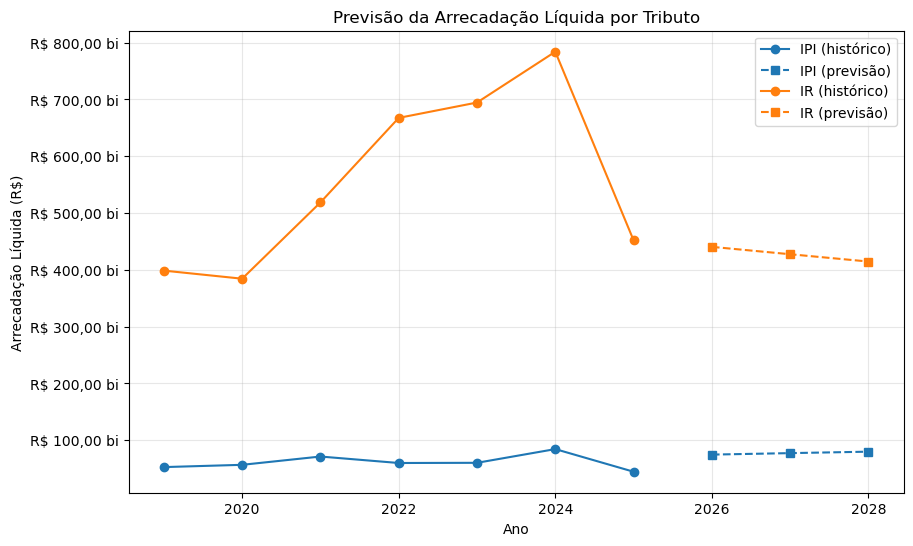

In [11]:
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter
import warnings
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.linear_model import LinearRegression

# Análise Preditiva — previsão da Arrecadação Líquida por Tributo (horizonte 3 anos)
import matplotlib.pyplot as plt

# Tentativa de usar ExponentialSmoothing; se não disponível, usar regressão linear como fallback
try:
    _USE_ES = True
except Exception:
    _USE_ES = False

warnings.filterwarnings("ignore")

# Usando a agregação anual já calculada em `dados_grafico`
ts = dados_grafico.pivot(index='Ano', columns='Tributo', values='Arrecadação Líquida').sort_index()

# Parâmetros de previsão
horizon = 3
max_year = int(ts.index.max())
future_years = np.arange(max_year + 1, max_year + 1 + horizon)

# Função auxiliar para formatar e exibir em R$
def format_brl(x):
    try:
        if pd.isna(x):
            return None
        s = f"{x:,.2f}"
        s = s.replace(',', 'X').replace('.', ',').replace('X', '.')
        return f"R$ {s}"
    except Exception:
        return x

# Dicionário para armazenar previsões
predictions = {}

for tributo in ts.columns:
    series = ts[tributo].astype(float).copy()
    years = np.array(series.index, dtype=int)

    if _USE_ES and len(series) >= 3:
        # Modelo Exponential Smoothing com tendência aditiva (damped)
        try:
            model = ExponentialSmoothing(series, trend='add', damped_trend=True, seasonal=None, initialization_method="estimated")
            fit = model.fit(optimized=True)
            pred = fit.forecast(horizon)
            pred.index = future_years
            predictions[tributo] = pred
        except Exception:
            # Fallback para regressão linear caso ES falhe
            X = years.reshape(-1, 1)
            reg = LinearRegression().fit(X, series.values)
            pred_vals = reg.predict(future_years.reshape(-1, 1))
            predictions[tributo] = pd.Series(pred_vals, index=future_years)
    else:
        # Regressão Linear simples sobre o ano
        X = years.reshape(-1, 1)
        reg = LinearRegression().fit(X, series.values)
        pred_vals = reg.predict(future_years.reshape(-1, 1))
        predictions[tributo] = pd.Series(pred_vals, index=future_years)

# Construir DataFrame com previsões
forecast_df = pd.DataFrame(predictions)
forecast_df.index.name = 'Ano'

# Mostrar previsões numéricas (formatadas)
forecast_fmt = forecast_df.copy()
for c in forecast_fmt.columns:
    forecast_fmt[c] = forecast_fmt[c].apply(format_brl)

print("Previsões da Arrecadação Líquida (próximos anos):")
display(forecast_fmt)

# Plot: histórico + previsões
plt.figure(figsize=(10, 6))
ax_pred = plt.gca()
colors = plt.cm.tab10.colors

for i, tributo in enumerate(ts.columns):
    # histórico
    ax_pred.plot(ts.index, ts[tributo], label=f"{tributo} (histórico)", marker='o', color=colors[i])
    # previsão
    ax_pred.plot(forecast_df.index, forecast_df[tributo], label=f"{tributo} (previsão)", linestyle='--', marker='s', color=colors[i])

# Formatação do eixo Y em R$ com escala (reaproveitando lógica já usada no notebook)
def format_brl_tick(x, pos):
    if abs(x) >= 1e9:
        valor = x / 1e9
        unidade = 'bi'
    elif abs(x) >= 1e6:
        valor = x / 1e6
        unidade = 'mi'
    elif abs(x) >= 1e3:
        valor = x / 1e3
        unidade = 'mil'
    else:
        valor = x
        unidade = ''
    s = f"{valor:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')
    return f"R$ {s} {unidade}"

ax_pred.yaxis.set_major_formatter(FuncFormatter(format_brl_tick))
ax_pred.set_title('Previsão da Arrecadação Líquida por Tributo')
ax_pred.set_xlabel('Ano')
ax_pred.set_ylabel('Arrecadação Líquida (R$)')
ax_pred.legend()
ax_pred.grid(alpha=0.3)
plt.show()

In [12]:
import pandas as pd

def escala_brl(valor):
    """Retorna o valor formatado em reais e a escala (mil, mi, bi)"""
    if abs(valor) >= 1e9:
        return f"R$ {valor/1e9:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.') + " bi"
    elif abs(valor) >= 1e6:
        return f"R$ {valor/1e6:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.') + " mi"
    elif abs(valor) >= 1e3:
        return f"R$ {valor/1e3:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.') + " mil"
    else:
        return f"R$ {valor:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')

# Agrupando dados por Ano e Tributo
dados_grafico = df.groupby(['Ano', 'Tributo'])['Arrecadação Líquida'].sum().reset_index()

# Adicionando coluna formatada
dados_grafico['Arrecadação Líquida Formatada'] = dados_grafico['Arrecadação Líquida'].apply(escala_brl)

# Exibindo resultado
print(dados_grafico[['Ano', 'Tributo', 'Arrecadação Líquida Formatada']].head(10))

    Ano Tributo Arrecadação Líquida Formatada
0  2019     IPI                   R$ 52,69 bi
1  2019      IR                  R$ 398,64 bi
2  2020     IPI                   R$ 56,69 bi
3  2020      IR                  R$ 384,39 bi
4  2021     IPI                   R$ 71,29 bi
5  2021      IR                  R$ 518,72 bi
6  2022     IPI                   R$ 59,89 bi
7  2022      IR                  R$ 667,55 bi
8  2023     IPI                   R$ 60,23 bi
9  2023      IR                  R$ 694,58 bi


In [13]:
# Análise Avançada — insights adicionais sobre a arrecadação líquida

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.linear_model import LinearRegression

# 1. Tendência futura da arrecadação líquida (total e por tributo)
dados_grafico = df.groupby(['Ano', 'Tributo'])['Arrecadação Líquida'].sum().reset_index()
ts = dados_grafico.pivot(index='Ano', columns='Tributo', values='Arrecadação Líquida').sort_index()

horizon = 3
max_year = int(ts.index.max())
future_years = np.arange(max_year + 1, max_year + 1 + horizon)

predictions = {}
for tributo in ts.columns:
    series = ts[tributo].astype(float).copy()
    years = np.array(series.index, dtype=int)
    if len(series) >= 3:
        try:
            model = ExponentialSmoothing(series, trend='add', damped_trend=True, seasonal=None, initialization_method="estimated")
            fit = model.fit(optimized=True)
            pred = fit.forecast(horizon)
            pred.index = future_years
            predictions[tributo] = pred
        except Exception:
            X = years.reshape(-1, 1)
            reg = LinearRegression().fit(X, series.values)
            pred_vals = reg.predict(future_years.reshape(-1, 1))
            predictions[tributo] = pd.Series(pred_vals, index=future_years)
    else:
        X = years.reshape(-1, 1)
        reg = LinearRegression().fit(X, series.values)
        pred_vals = reg.predict(future_years.reshape(-1, 1))
        predictions[tributo] = pd.Series(pred_vals, index=future_years)

forecast_df = pd.DataFrame(predictions)
forecast_df.index.name = 'Ano'

def format_brl_tick(x, pos):
    if abs(x) >= 1e9:
        valor = x / 1e9
        unidade = 'bi'
    elif abs(x) >= 1e6:
        valor = x / 1e6
        unidade = 'mi'
    elif abs(x) >= 1e3:
        valor = x / 1e3
        unidade = 'mil'
    else:
        valor = x
        unidade = ''
    s = f"{valor:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')
    return f"R$ {s} {unidade}"

In [14]:
# 2. Variação anual dos valores arrecadados
dados_ano = df.groupby('Ano')['Arrecadação Líquida'].sum().reset_index()
dados_ano['Variação (%)'] = dados_ano['Arrecadação Líquida'].pct_change() * 100

print("Variação anual da arrecadação líquida:")
print(dados_ano)

Variação anual da arrecadação líquida:
    Ano  Arrecadação Líquida  Variação (%)
0  2019         4.513212e+11           NaN
1  2020         4.410862e+11     -2.267775
2  2021         5.900072e+11     33.762324
3  2022         7.274402e+11     23.293444
4  2023         7.548086e+11      3.762294
5  2024         8.684181e+11     15.051427
6  2025         4.965468e+11    -42.821691


In [15]:
# 3. Impacto de eventos específicos sobre a arrecadação
eventos = ['Compensação', 'Restituição', 'Retificação']
impacto_eventos = df.groupby('Ano')[eventos + ['Arrecadação Líquida']].sum().reset_index()
for evento in eventos:
    impacto_eventos[f'Impacto_{evento}_%'] = (impacto_eventos[evento] / impacto_eventos['Arrecadação Líquida']) * 100

print("Impacto de eventos específicos sobre a arrecadação líquida:")
print(impacto_eventos[['Ano'] + [f'Impacto_{e}_%' for e in eventos]])

Impacto de eventos específicos sobre a arrecadação líquida:
    Ano  Impacto_Compensação_%  Impacto_Restituição_%  Impacto_Retificação_%
0  2019              -2.980523              -6.705967               2.889773
1  2020              -5.616886              -7.183635               0.068322
2  2021              -2.747791              -5.403433              -0.089652
3  2022              -0.987740              -5.760974               0.025341
4  2023              -1.195556              -6.183055               0.291720
5  2024              -0.607920              -5.929245               0.386657
6  2025               1.123228              -6.258211               0.504750


In [16]:
# 4. Projeção de arrecadação para próximos anos (milhões, bilhões)
print("Projeção da arrecadação líquida para os próximos anos (por tributo):")
for tributo in forecast_df.columns:
    print(f"\nTributo: {tributo}")
    for ano, valor in forecast_df[tributo].items():
        print(f"{ano}: {format_brl_tick(valor, None)}")

Projeção da arrecadação líquida para os próximos anos (por tributo):

Tributo: IPI
2026: R$ 74,68 bi
2027: R$ 77,28 bi
2028: R$ 79,84 bi

Tributo: IR
2026: R$ 440,47 bi
2027: R$ 427,47 bi
2028: R$ 414,60 bi



Crescimento médio anual por tributo (%):
Tributo
IPI    1.800001
IR     5.774131
dtype: float64


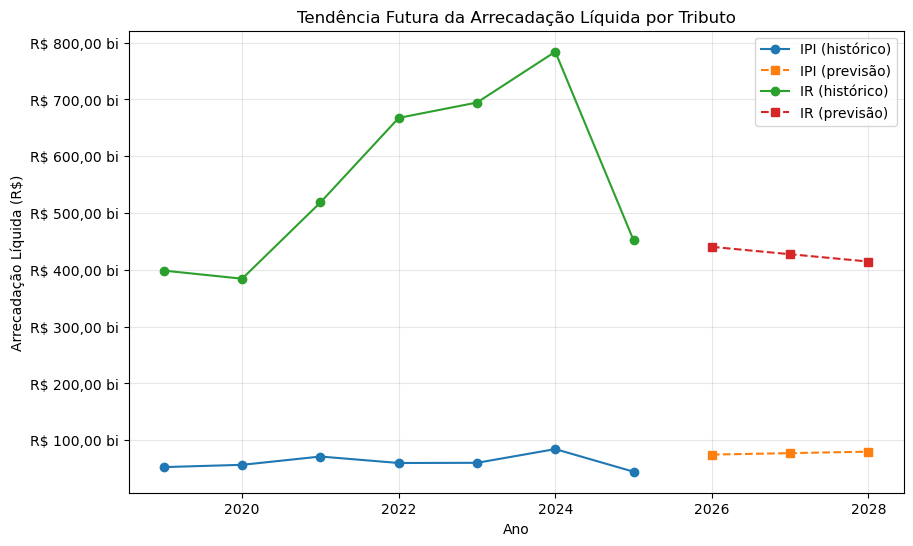

In [17]:
# 5. Comparação entre tributos para identificar tendência
crescimento = ts.pct_change().mean() * 100
print("\nCrescimento médio anual por tributo (%):")
print(crescimento)

# Visualização da tendência futura
plt.figure(figsize=(10, 6))
for tributo in ts.columns:
    plt.plot(ts.index, ts[tributo], label=f"{tributo} (histórico)", marker='o')
    plt.plot(forecast_df.index, forecast_df[tributo], label=f"{tributo} (previsão)", linestyle='--', marker='s')
plt.ylabel('Arrecadação Líquida (R$)')
plt.xlabel('Ano')
plt.title('Tendência Futura da Arrecadação Líquida por Tributo')
plt.legend()
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_brl_tick))
plt.grid(alpha=0.3)
plt.show()

### 3 - Análise *Prescritiva* com base para conhecer o que está acontecendo, bem como o que deve vir a acontecer, e tomar decisões para garantir o melhor desempenho possível.

- Objetivo: Sugerir ações para melhorar resultados futuros, com base nas análises anteriores.
- Exemplos no notebook: Recomendações para priorizar tributos com maior crescimento, mitigar eventos que reduzem arrecadação, propor políticas e estratégias para maximizar a arrecadação.
- Responde perguntas como: "O que fazer para aumentar a arrecadação?", "Como reduzir perdas?", "Quais ações podem melhorar o desempenho?"

In [18]:
# Análise Prescritiva — recomendações para maximizar a arrecadação líquida
# Baseando-se nas análises anteriores:

# 1. Identificando tributo com maior crescimento médio anual
tributo_maior_crescimento = crescimento.idxmax()
taxa_maior_crescimento = crescimento.max()
print(f"O tributo com maior crescimento médio anual é '{tributo_maior_crescimento}' ({taxa_maior_crescimento:.2f}%).")

# 2. Identificando evento que mais impacta negativamente a arrecadação líquida
impactos_medios = impacto_eventos[[f'Impacto_{e}_%' for e in eventos]].mean()
evento_maior_impacto = impactos_medios.idxmin()
evento_maior_impacto_nome = evento_maior_impacto.replace('Impacto_', '').replace('_%', '')
print(f"O evento que mais reduz a arrecadação líquida, em média, é '{evento_maior_impacto_nome}' ({impactos_medios.min():.2f}%).")

# 3. Recomendações prescritivas
print("\nRecomendações prescritivas:")
print(f"- Priorizar políticas e ações que estimulem o crescimento do tributo '{tributo_maior_crescimento}', pois apresenta maior potencial de aumento de arrecadação.")
print(f"- Implementar controles e revisões para mitigar o impacto negativo do evento '{evento_maior_impacto_nome}', reduzindo perdas na arrecadação líquida.")
print("- Monitorar variações anuais e ajustar estratégias conforme tendências observadas nos dados históricos e previsões futuras.")
print("- Avaliar oportunidades de digitalização, automação e fiscalização para aumentar eficiência e reduzir fraudes ou erros nos processos de arrecadação.")

O tributo com maior crescimento médio anual é 'IR' (5.77%).
O evento que mais reduz a arrecadação líquida, em média, é 'Restituição' (-6.20%).

Recomendações prescritivas:
- Priorizar políticas e ações que estimulem o crescimento do tributo 'IR', pois apresenta maior potencial de aumento de arrecadação.
- Implementar controles e revisões para mitigar o impacto negativo do evento 'Restituição', reduzindo perdas na arrecadação líquida.
- Monitorar variações anuais e ajustar estratégias conforme tendências observadas nos dados históricos e previsões futuras.
- Avaliar oportunidades de digitalização, automação e fiscalização para aumentar eficiência e reduzir fraudes ou erros nos processos de arrecadação.
